In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv(r"C:\Users\KEYRUN\OneDrive\Desktop\Indian personal loan  risk\loan_default_cleaned.csv")

In [6]:
df.shape

(25000, 22)

In [8]:
df.head()

,applicant_id,age,gender,marital_status,city_tier,state,employment_type,bank_account_vintage_years,monthly_income_inr,existing_loans_count,...,num_credit_inquiries_last_6m,late_payments_last_12m,loan_amount_requested_inr,loan_tenure_months,loan_purpose,collateral_provided,cibil_score,interest_rate_offered_pct,default_risk_score,default_flag
0,APP100000,38,Male,Married,Tier 1,Bihar,Salaried - Government,9.3,727000,2,...,3,0,1519000,60,Home Renovation,Yes,635,26.0,0.96,0
1,APP100001,26,Male,Married,Tier 2,Rajasthan,Salaried - Private,0.8,588300,1,...,0,1,1372000,36,Medical Emergency,No,619,26.0,1.15,0
2,APP100002,42,Female,Married,Tier 1,West Bengal,Business Owner,6.5,574500,1,...,1,1,1322000,24,Home Renovation,No,619,26.0,9.66,0
3,APP100003,43,Female,Married,Tier 2,Maharashtra,Salaried - Private,4.6,569500,3,...,0,5,1233000,36,Vehicle Purchase,Yes,618,26.0,2.20,0
4,APP100004,21,Female,Married,Tier 2,Kerala,Salaried - Private,7.0,517300,3,...,1,0,1233000,48,Vehicle Purchase,Yes,617,26.0,2.03,0


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   applicant_id                  25000 non-null  object 
 1   age                           25000 non-null  int64  
 2   gender                        25000 non-null  object 
 3   marital_status                25000 non-null  object 
 4   city_tier                     25000 non-null  object 
 5   state                         25000 non-null  object 
 6   employment_type               25000 non-null  object 
 7   bank_account_vintage_years    25000 non-null  float64
 8   monthly_income_inr            25000 non-null  int64  
 9   existing_loans_count          25000 non-null  int64  
 10  existing_emi_monthly_inr      25000 non-null  int64  
 11  credit_utilization_ratio_pct  25000 non-null  float64
 12  num_credit_inquiries_last_6m  25000 non-null  int64  
 13  l

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,25000.0,35.303520,8.561309,21.00,29.00,35.00,41.0000,65.00
bank_account_vintage_years,25000.0,3.981652,3.873994,0.50,1.20,2.80,5.4000,25.00
monthly_income_inr,25000.0,54832.428000,38347.488163,12000.00,29500.00,45100.00,68700.0000,727000.00
existing_loans_count,25000.0,1.103720,1.051421,0.00,0.00,1.00,2.0000,6.00
existing_emi_monthly_inr,25000.0,11651.524000,10200.903137,0.00,5200.00,9000.00,14900.0000,202300.00
credit_utilization_ratio_pct,25000.0,41.590360,19.804901,0.00,27.80,41.30,55.0000,100.00
num_credit_inquiries_last_6m,25000.0,1.295880,1.131153,0.00,0.00,1.00,2.0000,9.00
late_payments_last_12m,25000.0,1.446680,1.271071,0.00,0.00,1.00,2.0000,8.00
loan_amount_requested_inr,25000.0,158457.240000,104231.469046,25000.00,88000.00,133000.00,199000.0000,1519000.00
loan_tenure_months,25000.0,42.401760,19.223168,12.00,24.00,36.00,60.0000,84.00


In [11]:
df['default_flag'].value_counts()

default_flag
0    23465
1     1535
Name: count, dtype: int64

In [12]:
df['default_flag'].value_counts(normalize=True) * 100

default_flag
0    93.86
1     6.14
Name: proportion, dtype: float64

In [13]:
corr = df.select_dtypes(include='number').corr()['default_flag'].sort_values(ascending=False)
corr

default_flag                    1.000000
default_risk_score              0.483996
interest_rate_offered_pct       0.114309
loan_amount_requested_inr       0.073801
monthly_income_inr              0.071063
existing_emi_monthly_inr        0.066387
existing_loans_count            0.029127
credit_utilization_ratio_pct    0.008429
loan_tenure_months              0.005420
num_credit_inquiries_last_6m    0.002478
bank_account_vintage_years      0.000786
age                            -0.002762
late_payments_last_12m         -0.007689
cibil_score                    -0.309941
Name: default_flag, dtype: float64

Higher CIBIL → lower default tendency.
Higher default-risk score → higher default tendency.
CIBIL has a considerably stronger relationship with default than income, loan amount, EMI, or credit utilization.

In [14]:
cibil_bins = [0, 549, 649, 749, 1000]
cibil_labels = ['Below 550', '550-649', '650-749', '750+']

df['cibil_range'] = pd.cut(
    df['cibil_score'],
    bins=cibil_bins,
    labels=cibil_labels
)

cibil_default = (
    df.groupby('cibil_range', observed=True)['default_flag']
      .mean()
      .mul(100)
)

cibil_default

cibil_range
Below 550    23.768965
550-649       4.262271
650-749       0.770200
750+          0.000000
Name: default_flag, dtype: float64

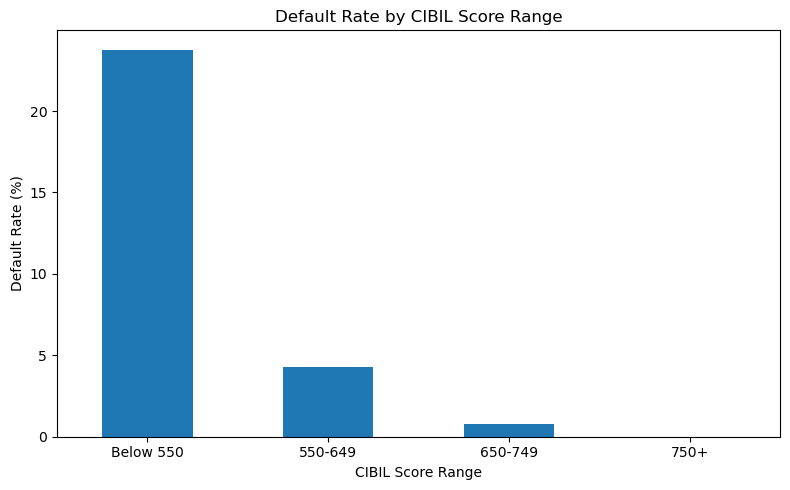

In [15]:
plt.figure(figsize=(8,5))

cibil_default.plot(kind='bar')

plt.title('Default Rate by CIBIL Score Range')
plt.xlabel('CIBIL Score Range')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

  ------------------------------    Loan Amount Analysis  -----------------------------------

In [16]:
loan_bins = [0, 100000, 300000, 500000, float('inf')]
loan_labels = ['Below 1L', '1L-2.99L', '3L-4.99L', '5L+']

df['loan_amount_range'] = pd.cut(
    df['loan_amount_requested_inr'],
    bins=loan_bins,
    labels=loan_labels
)

loan_default = (
    df.groupby('loan_amount_range', observed=True)['default_flag']
      .mean()
      .mul(100)
)

loan_default

loan_amount_range
Below 1L    1.792159
1L-2.99L    8.194622
3L-4.99L    8.300836
5L+         7.854985
Name: default_flag, dtype: float64

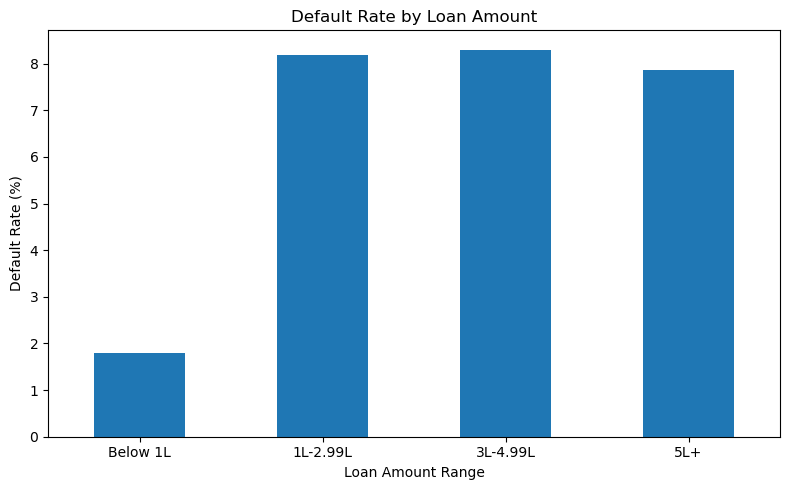

In [17]:
plt.figure(figsize=(8,5))

loan_default.plot(kind='bar')

plt.title('Default Rate by Loan Amount')
plt.xlabel('Loan Amount Range')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

----------------------------------------   Collateral Analysis  -----------------------------------------------

In [18]:
collateral_default = (
    df.groupby('collateral_provided')['default_flag']
      .mean()
      .mul(100)
)

collateral_default

collateral_provided
No     6.854364
Yes    3.586459
Name: default_flag, dtype: float64

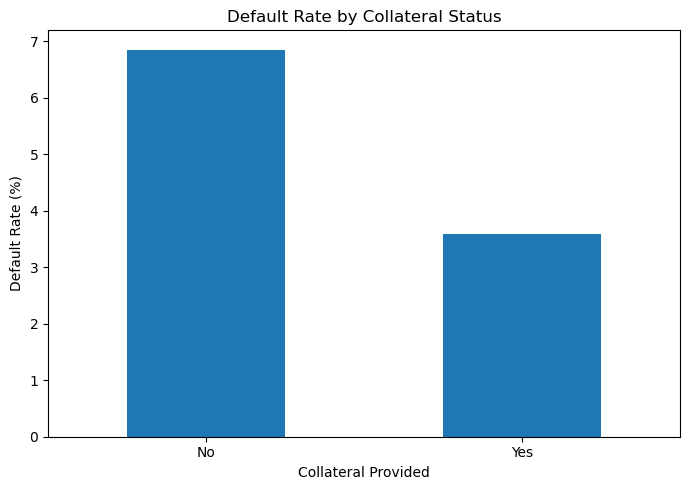

In [19]:
plt.figure(figsize=(7,5))

collateral_default.plot(kind='bar')

plt.title('Default Rate by Collateral Status')
plt.xlabel('Collateral Provided')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

------------------------------------      Statistical Validation: CIBIL vs Default     --------------------------------------

In [20]:
from scipy.stats import ttest_ind

defaulted = df[df['default_flag'] == 1]['cibil_score']
non_defaulted = df[df['default_flag'] == 0]['cibil_score']

t_stat, p_value = ttest_ind(
    defaulted,
    non_defaulted,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -52.10938169546929
P-value: 0.0
